All libraries successfully imported.
Current working directory: C:\Users\luke3\Documents\GitHub\Earnings Call Analyzer\notebooks


## Enhanced Sentiment Analysis

Showing 5 visualization files



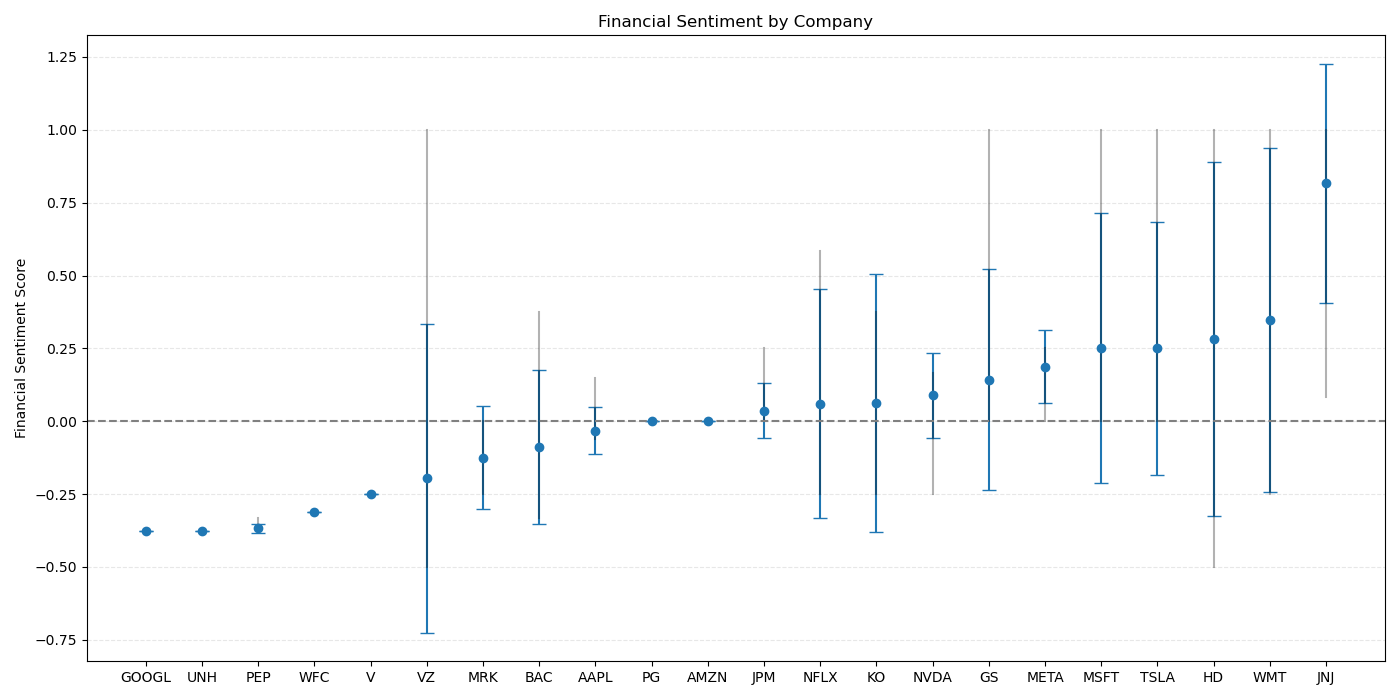
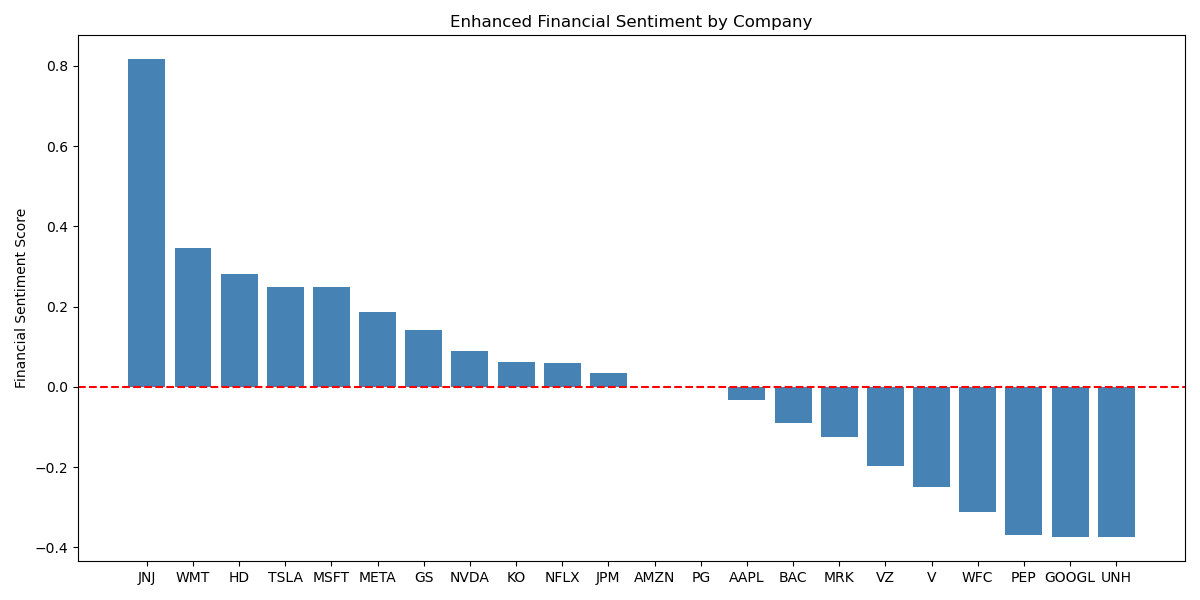
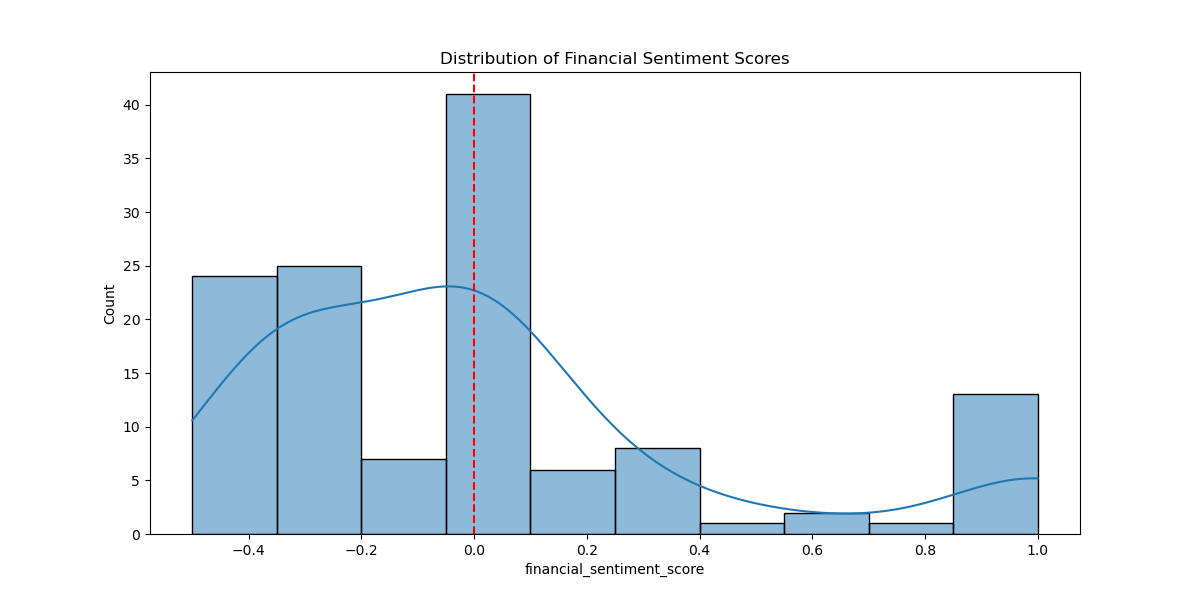
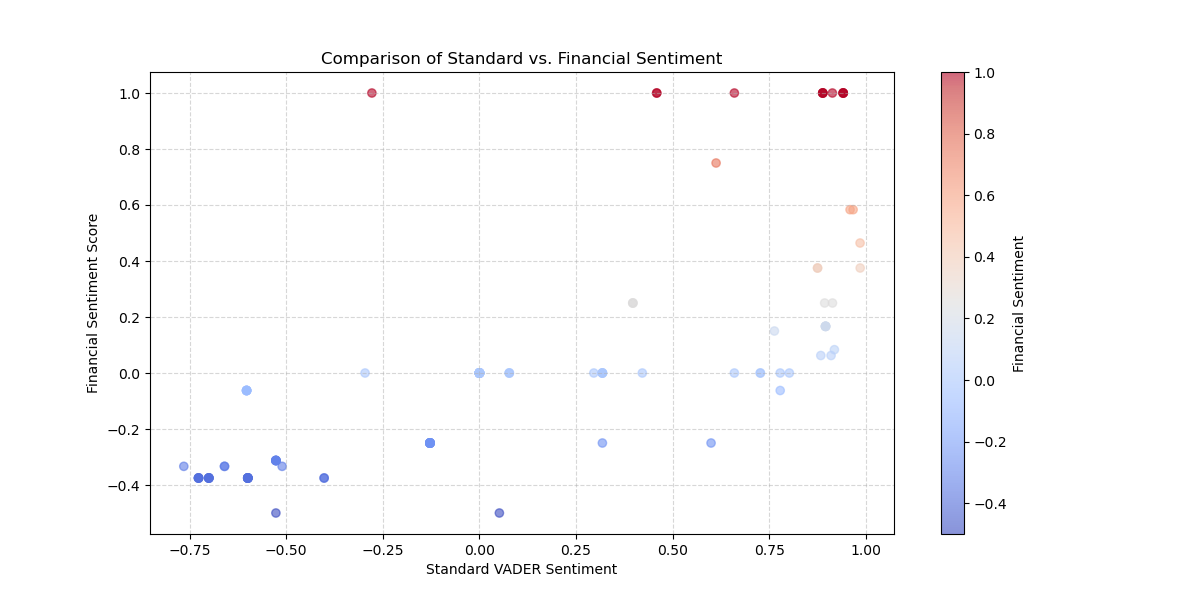
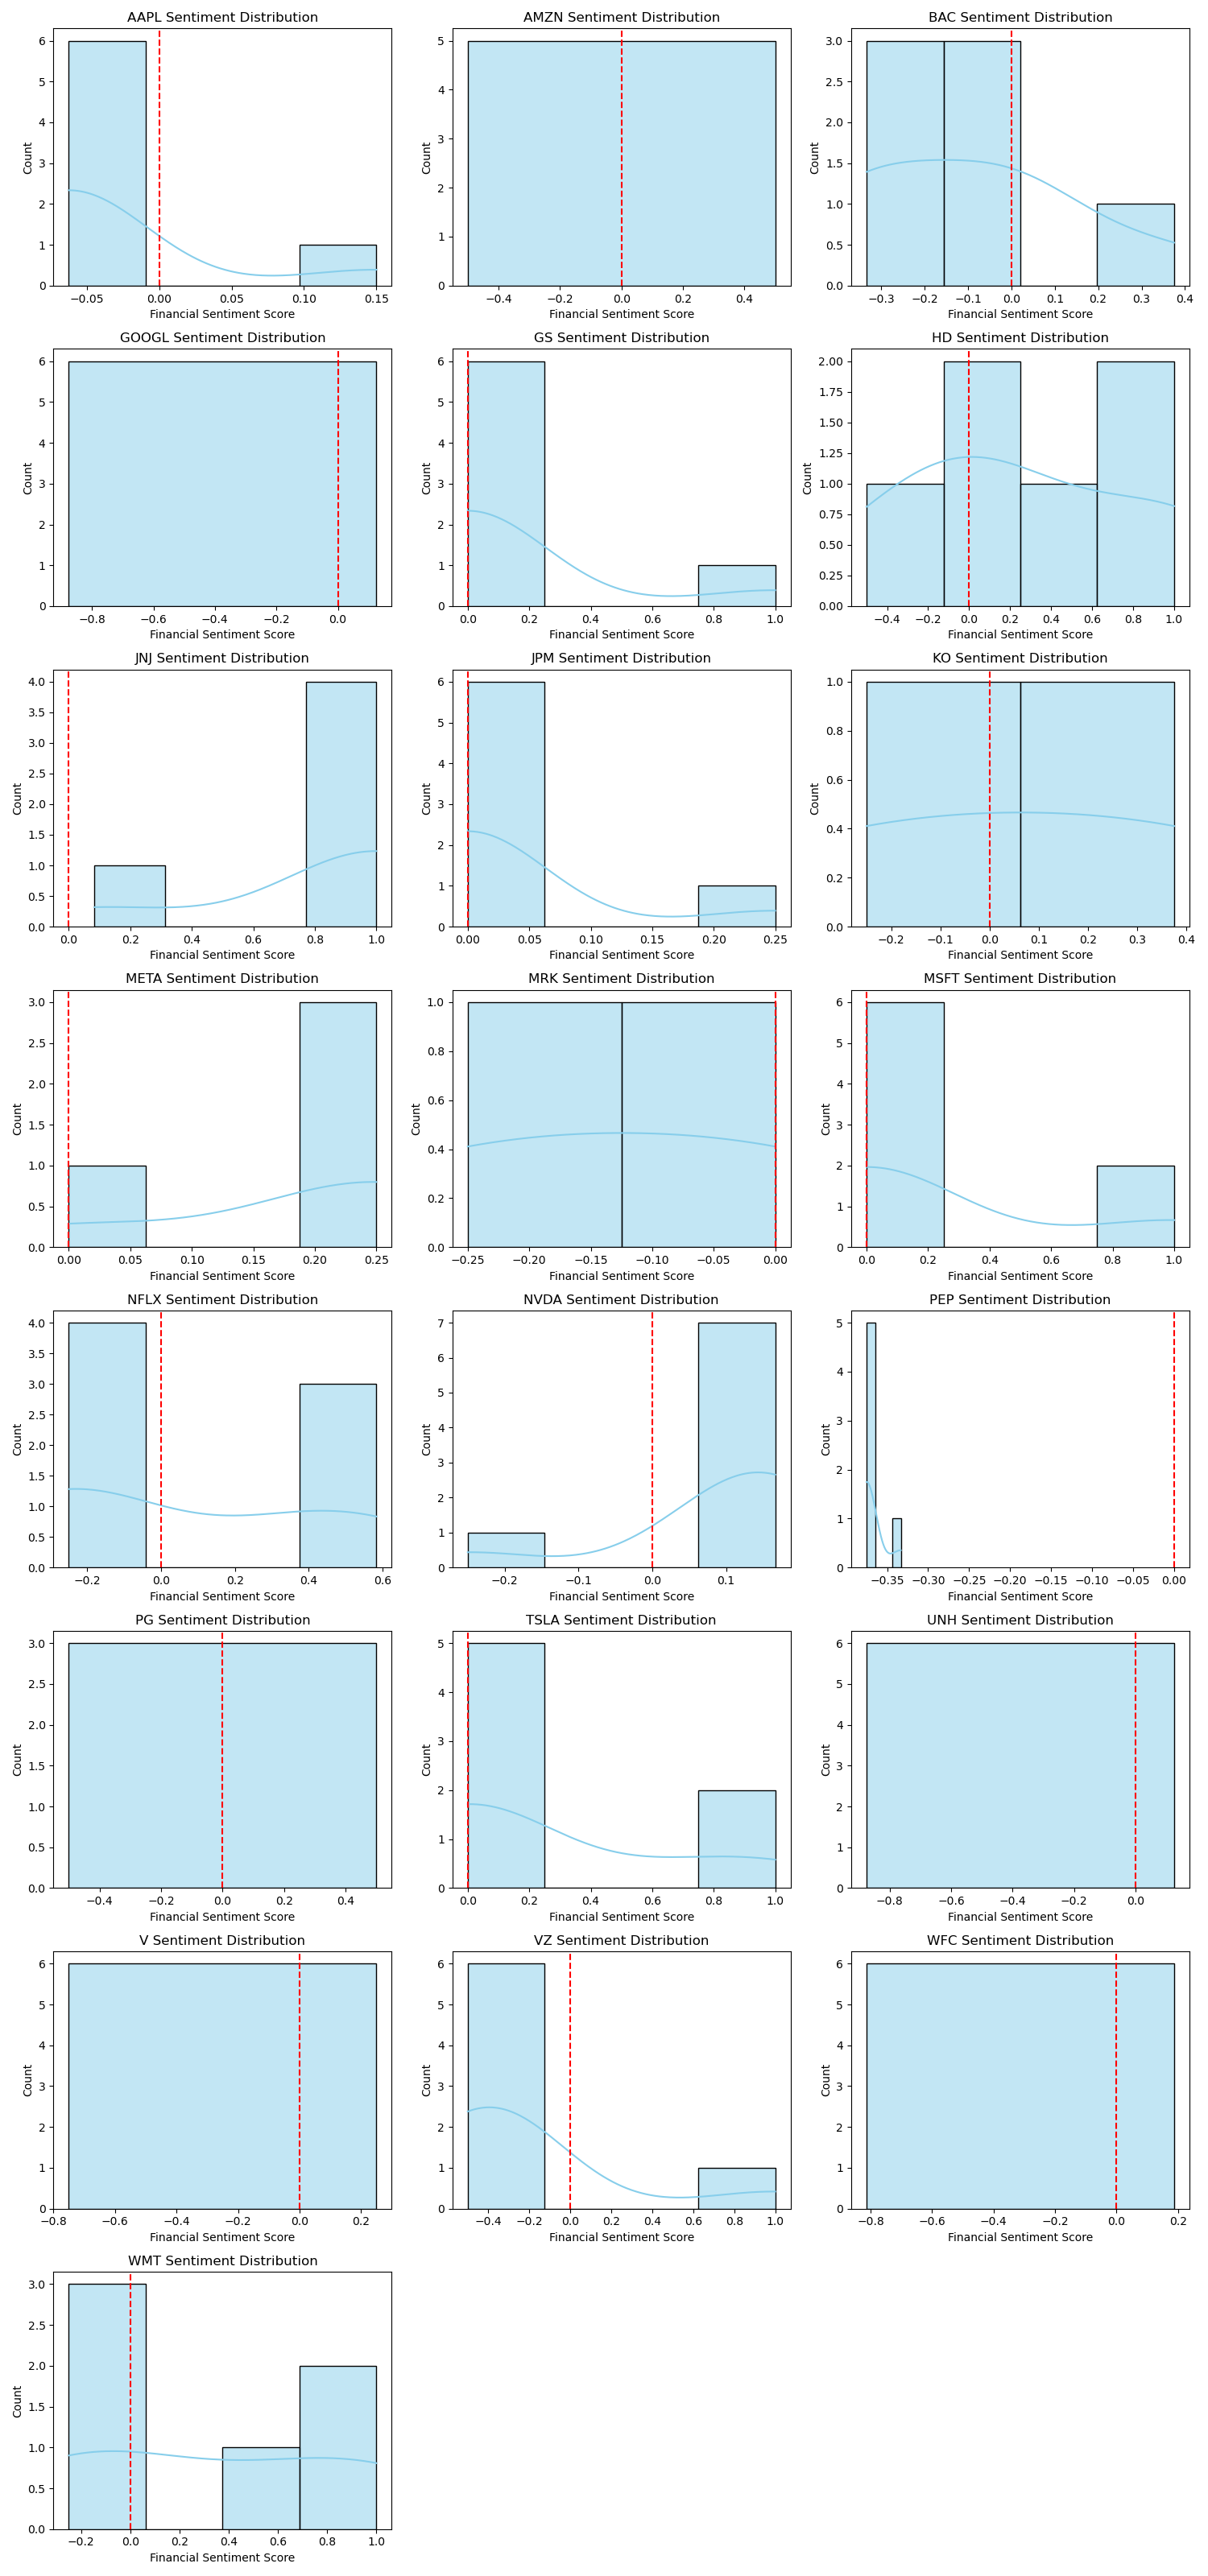

## Stock Return Correlation

Showing 4 visualization files



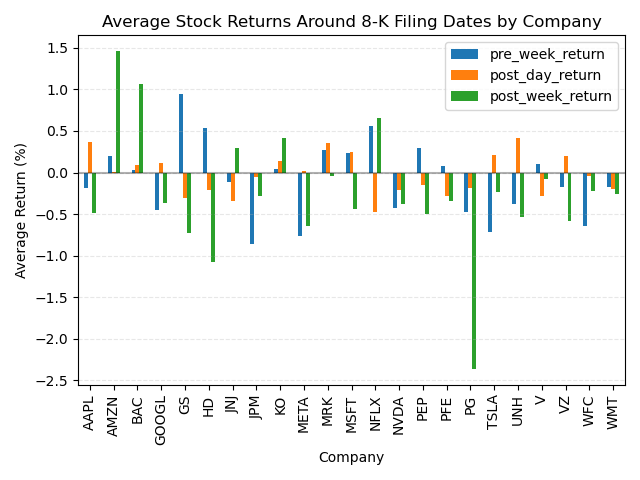
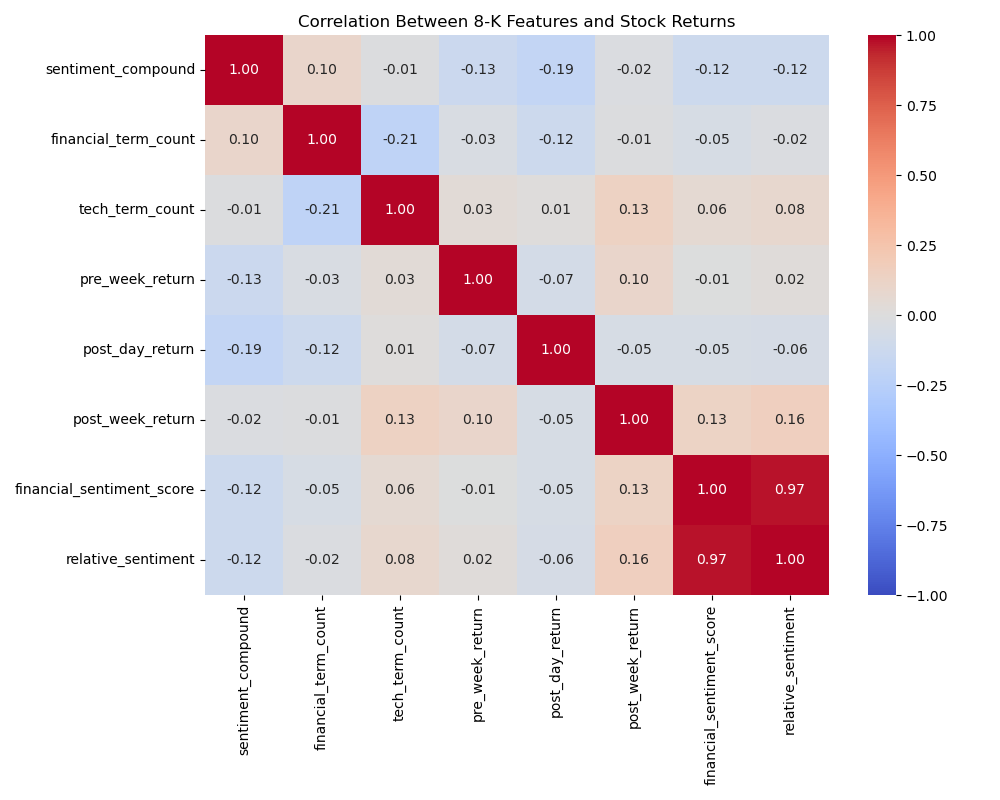
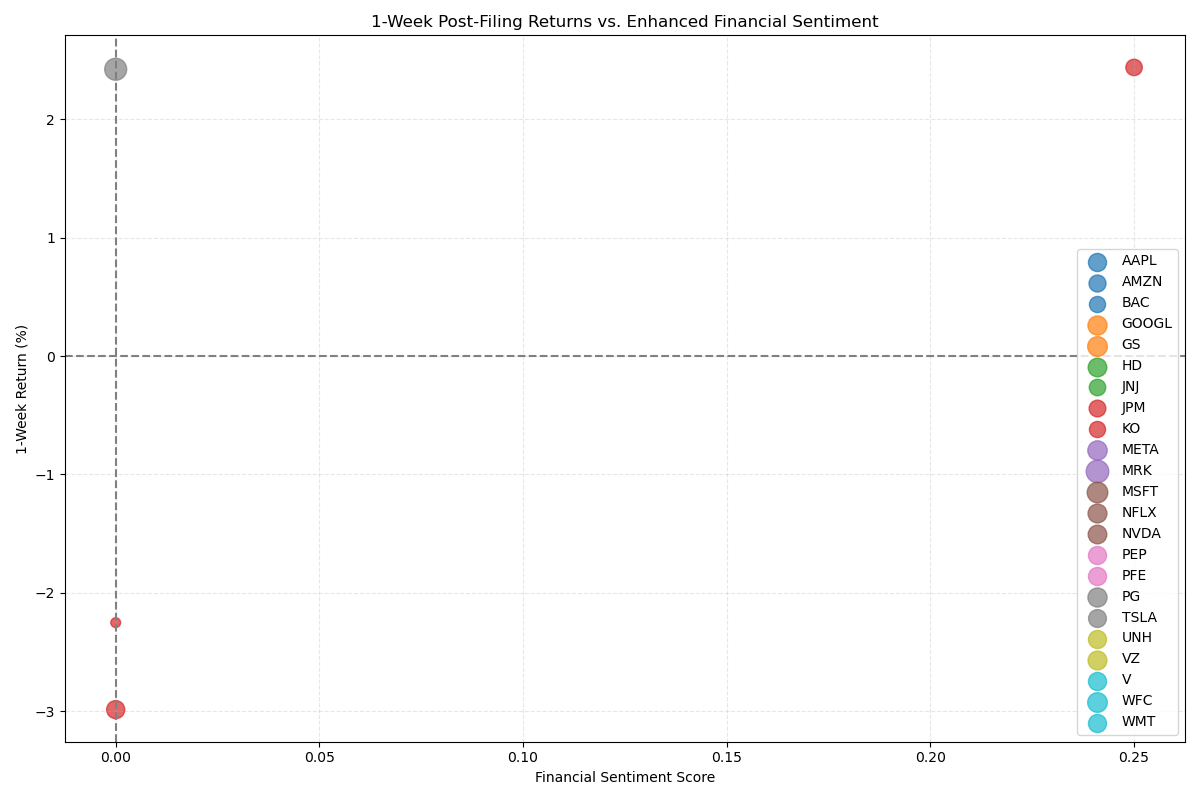
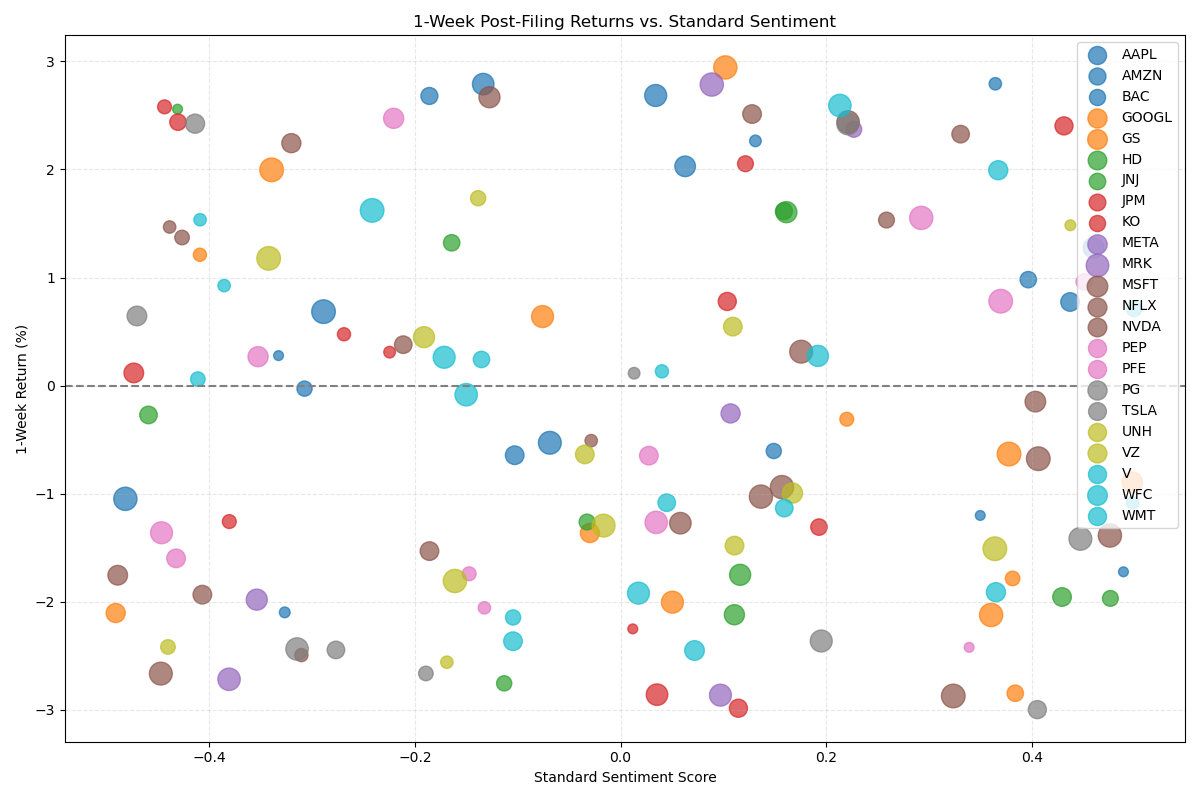

DataFrame columns: ['ticker', 'filing_date', 'sentiment_compound', 'financial_term_count', 'tech_term_count', 'pre_week_return', 'post_day_return', 'post_week_return', 'financial_sentiment_score', 'relative_sentiment']
Error creating analysis: Axis limits cannot be NaN or Inf
Traceback (most recent call last):
  File "C:\Users\luke3\AppData\Local\Temp\ipykernel_12340\2354429429.py", line 195, in create_industry_analysis
    plt.ylim(min_y, max_y)  # Set consistent y limits
    ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\luke3\anaconda3\Lib\site-packages\matplotlib\pyplot.py", line 1998, in ylim
    ret = ax.set_ylim(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\luke3\anaconda3\Lib\site-packages\matplotlib\axes\_base.py", line 3898, in set_ylim
    return self.yaxis._set_lim(bottom, top, emit=emit, auto=auto)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\luke3\anaconda3\Lib\site-packages\matplotlib\axis.py", line 1210, in _set_

## Executive Summary - Industry and Top Performers

Showing 14 visualization files



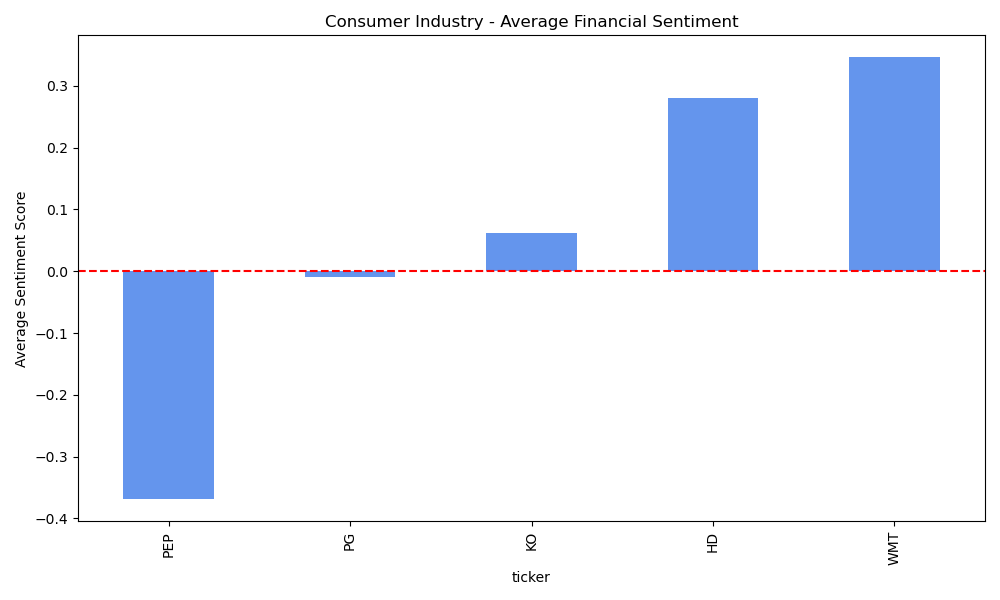
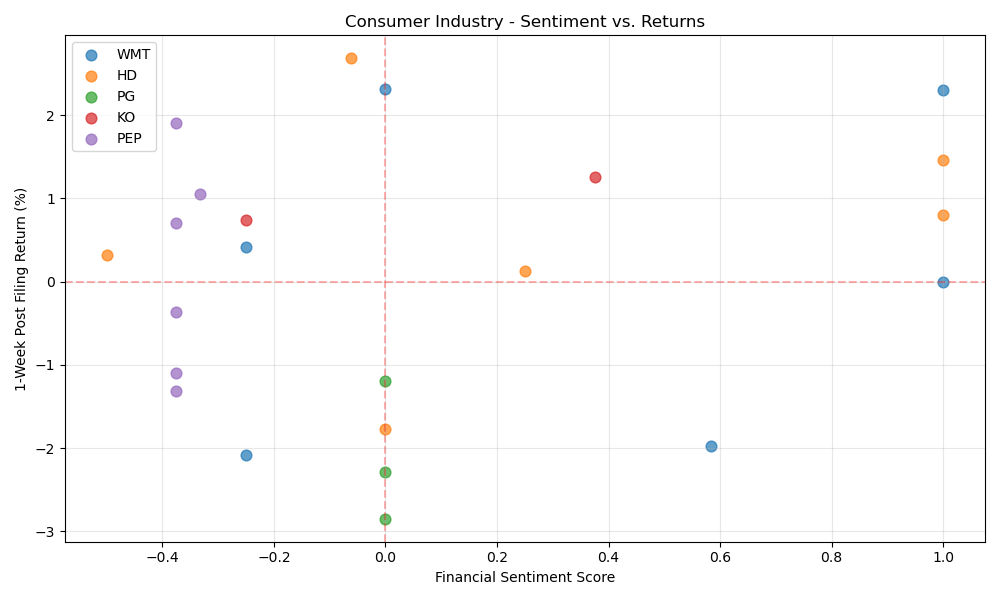
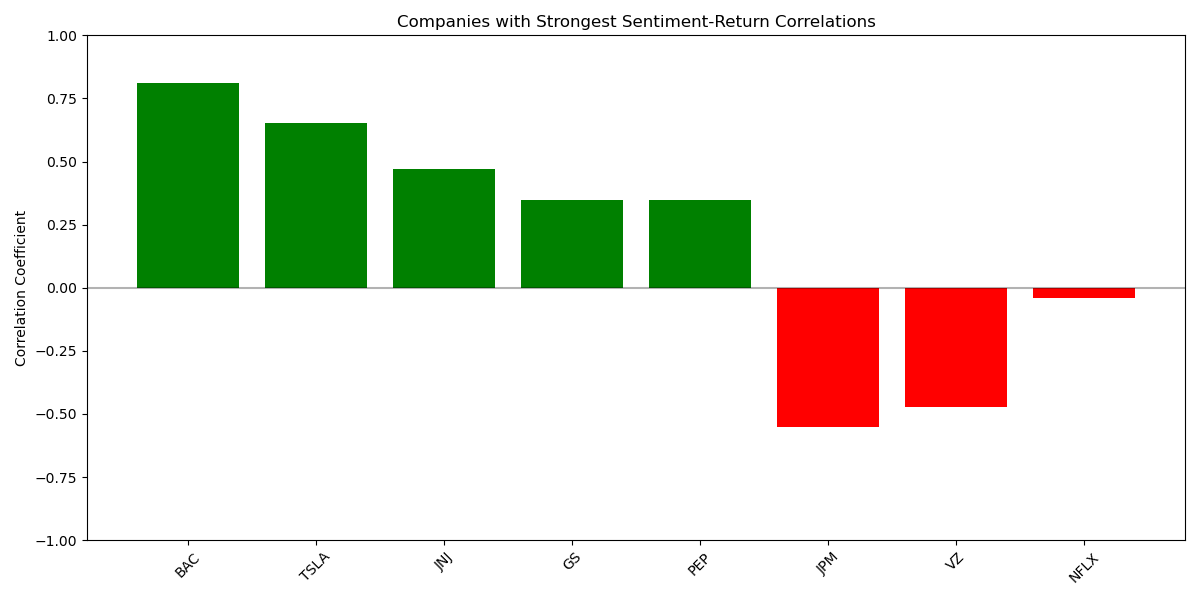
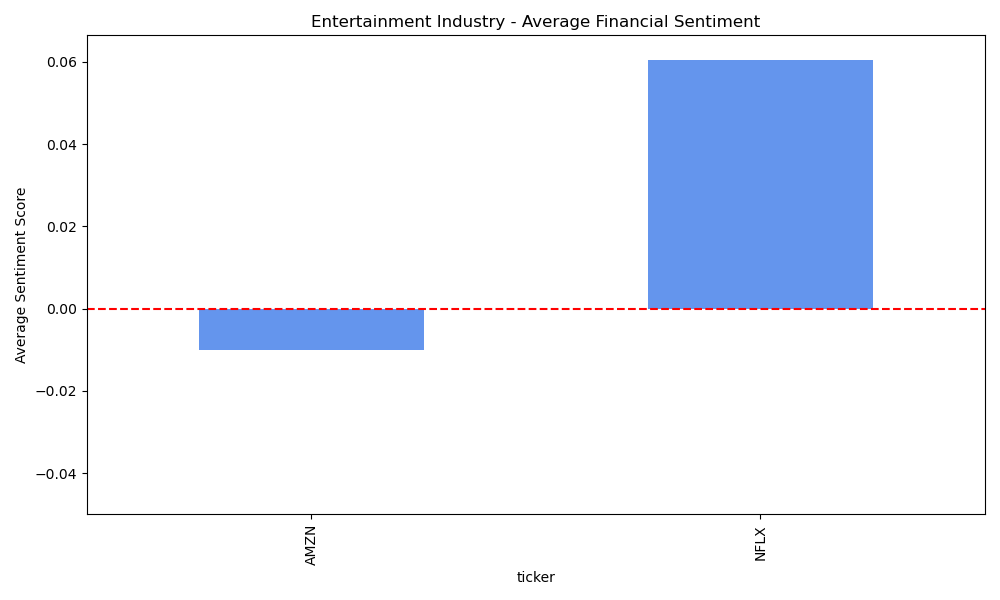
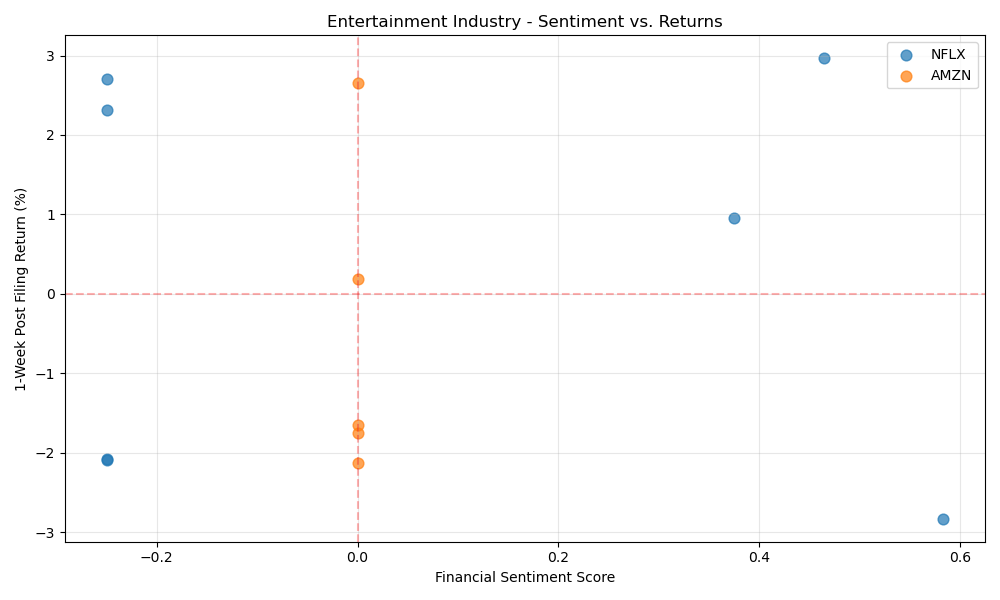
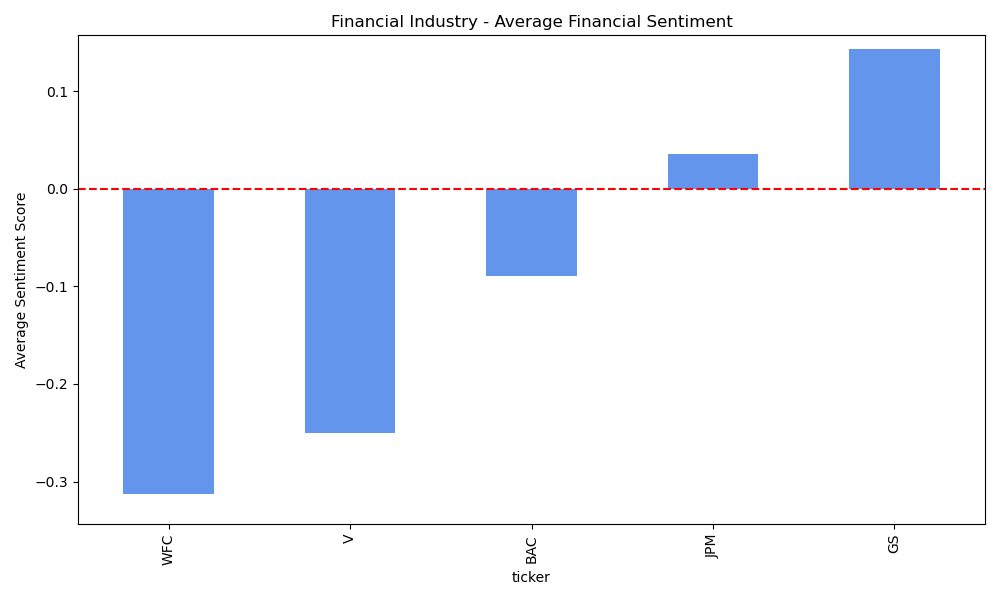
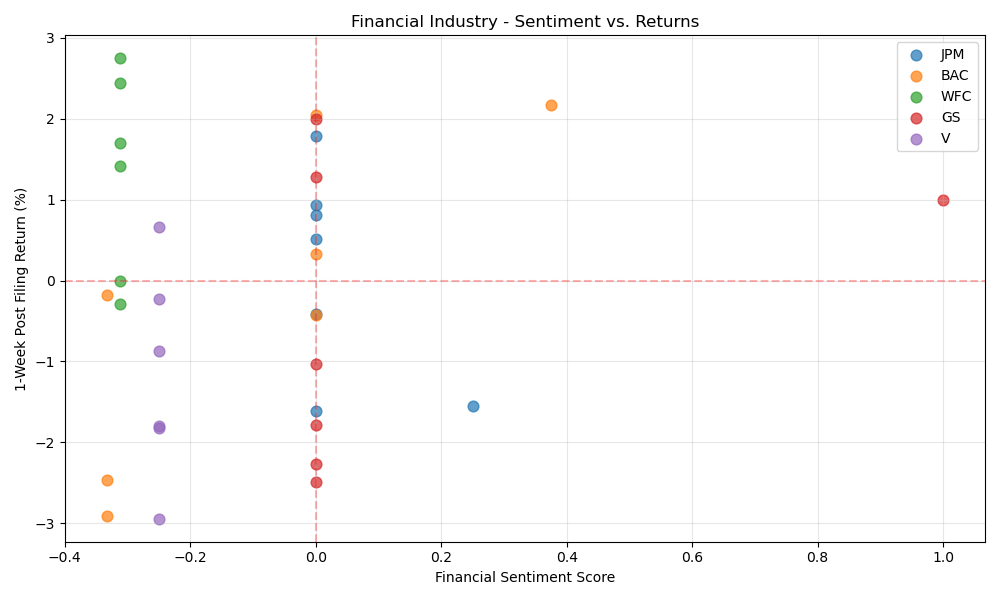
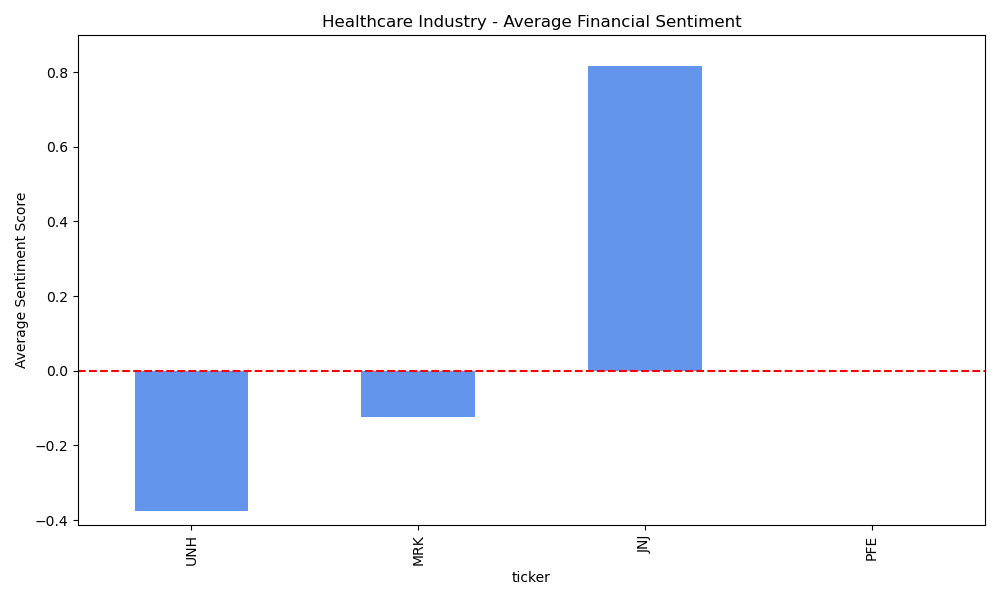
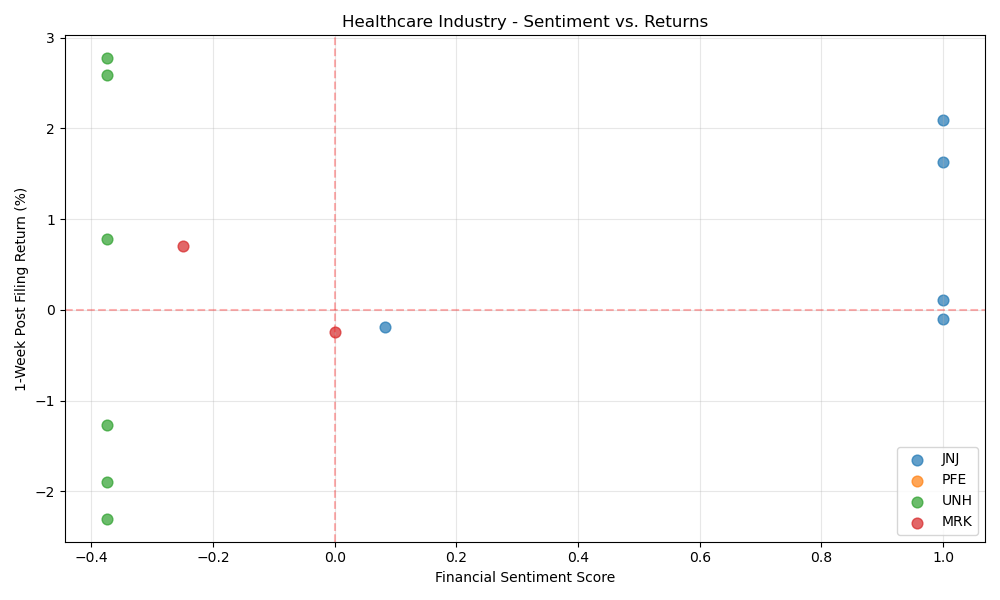
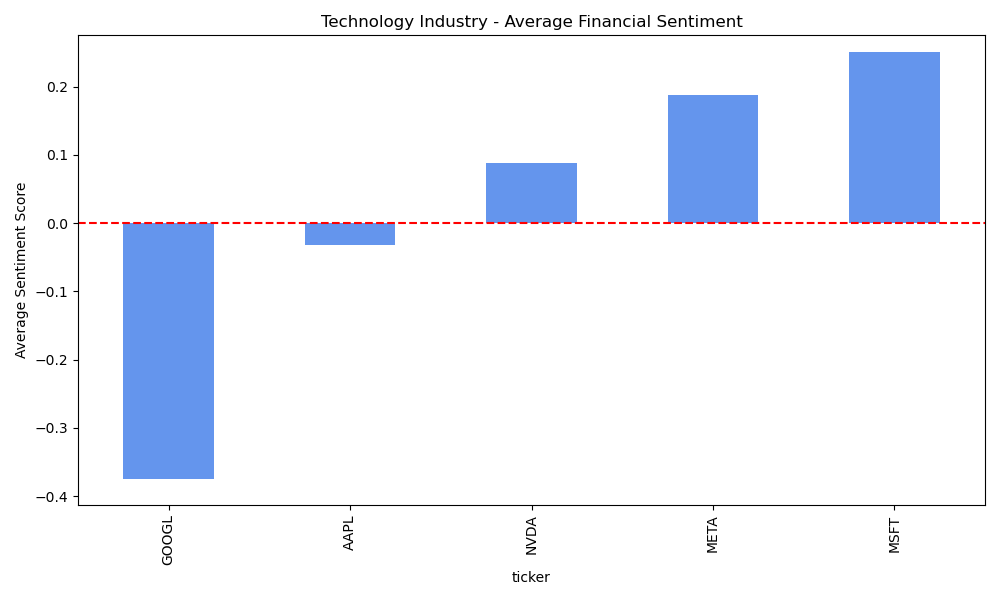
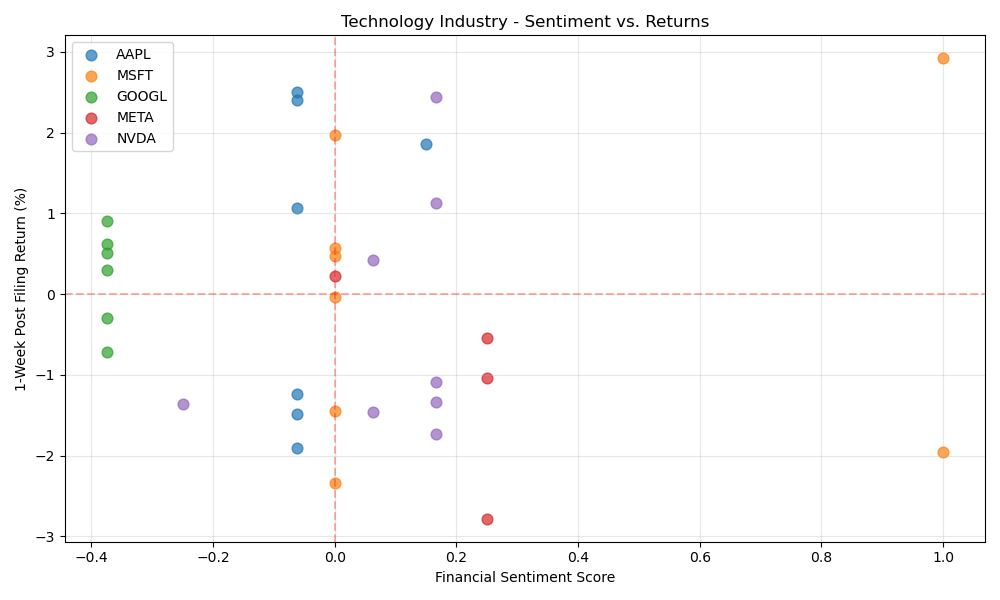
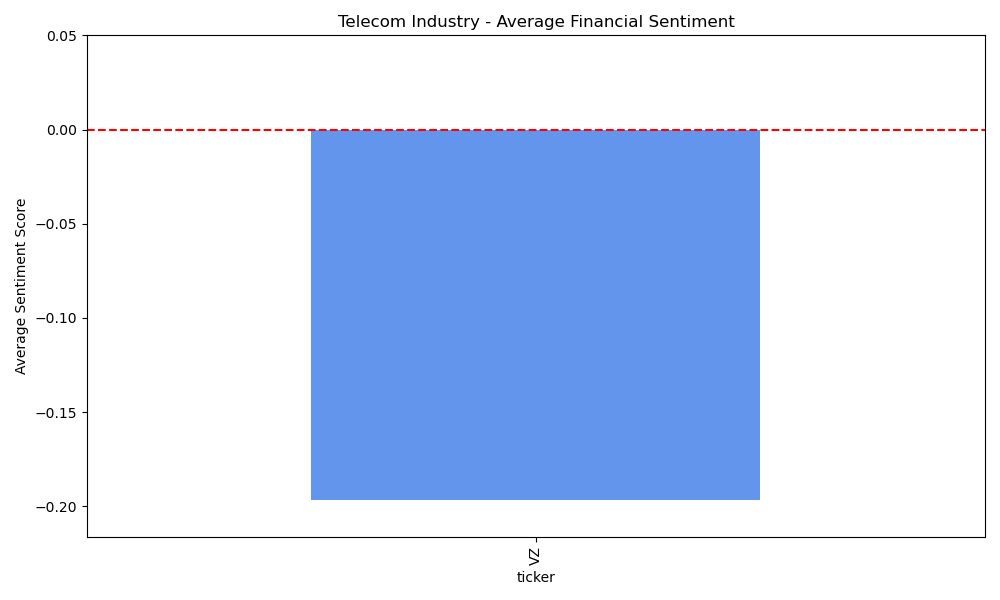
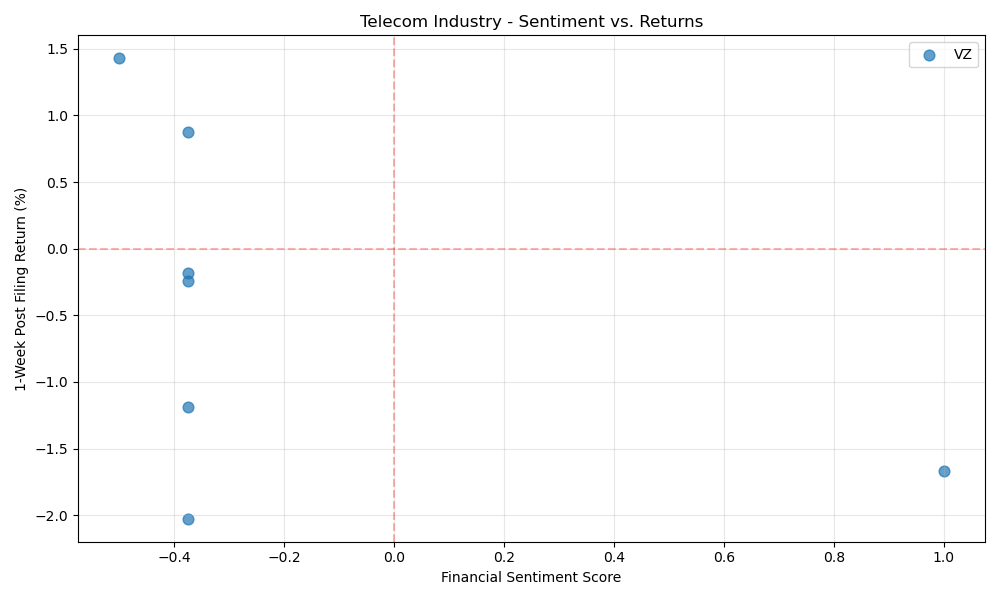
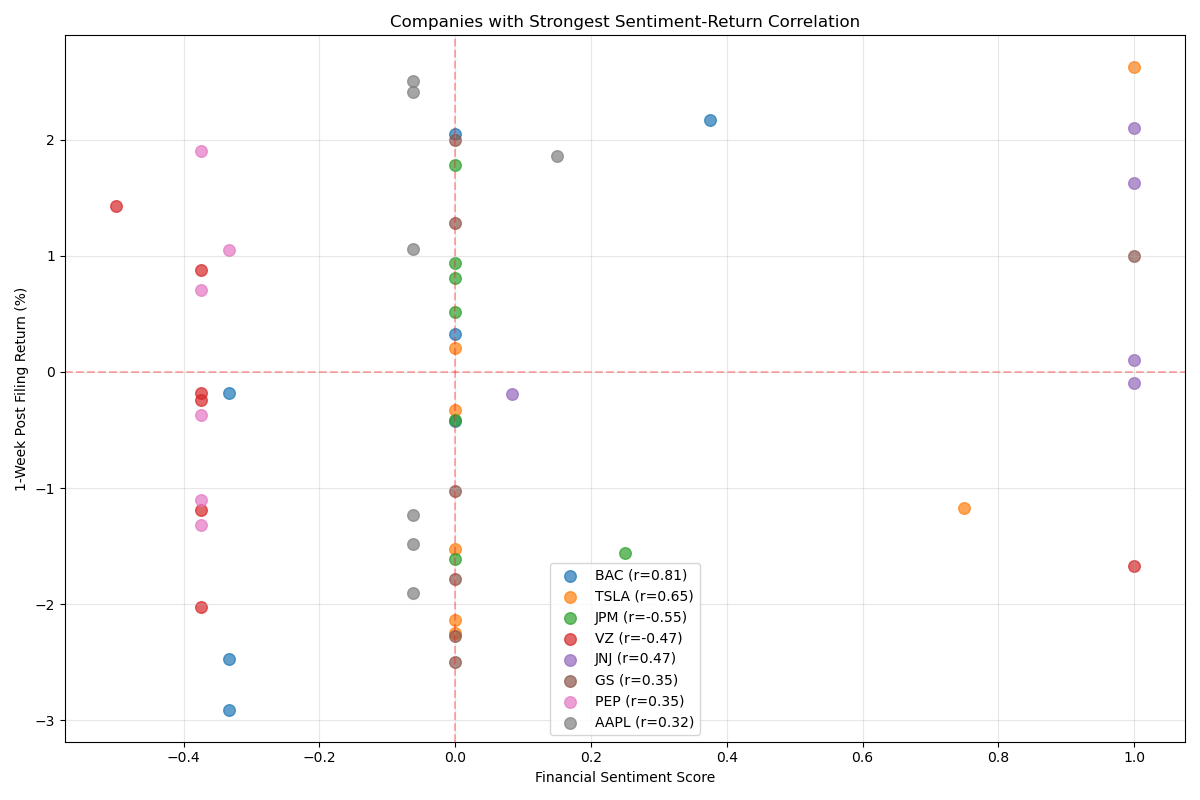

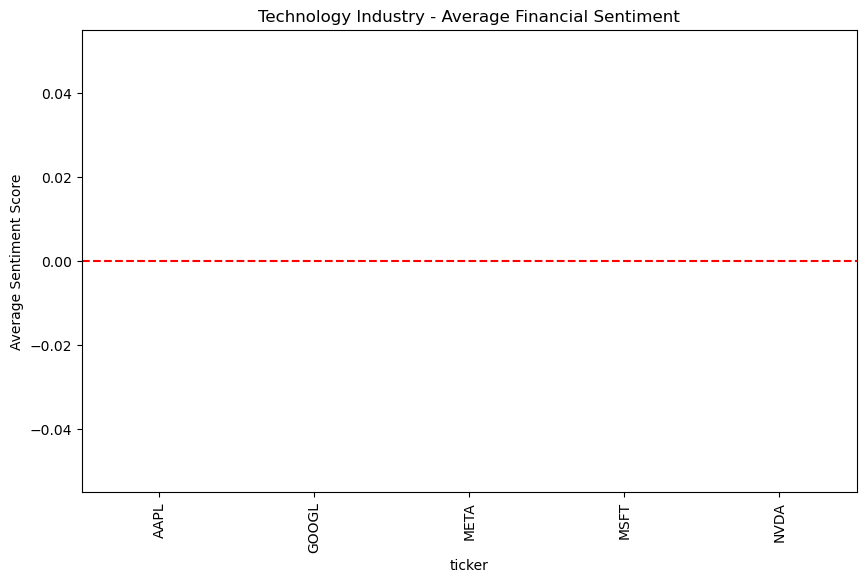

In [12]:
# === LIBRARY IMPORTS ===
try:
    import os
    import sys
    from pathlib import Path
    from IPython.display import Image, display, Markdown, HTML
    import glob
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import base64  # Added for image encoding

    print("All libraries successfully imported.")
except ImportError as e:
    print(f"Error importing libraries: {e}")
    print("Please install required libraries using: pip install pandas numpy matplotlib ipython")
    sys.exit(1)

# Import centralized configuration
from config import BASE_DIR, DATA_DIR, OUTPUT_DIR

# Function to display selected visualizations from a folder in a grid layout
def show_visualizations(folder_path, title=None, exclude_patterns=None, limit=None, columns=3):
    """Display visualizations in a grid layout

    Args:
        folder_path (str): Path to folder containing visualizations
        title (str, optional): Section title
        exclude_patterns (list, optional): List of patterns to exclude
        limit (int, optional): Maximum number of images to display
        columns (int, optional): Number of columns in the grid (default 3)
    """
    # Create absolute path
    abs_folder_path = folder_path if os.path.isabs(folder_path) else os.path.join(BASE_DIR, folder_path)

    if title:
        display(Markdown(f"## {title}"))

    # Check if folder exists
    if not os.path.exists(abs_folder_path):
        print(f"⚠️ Folder not found: {abs_folder_path}")
        return

    # Get all PNG files
    image_files = sorted(glob.glob(f"{abs_folder_path}/*.png"))

    # Apply exclusion patterns if specified
    if exclude_patterns:
        for pattern in exclude_patterns:
            image_files = [f for f in image_files if pattern not in f]

    # Apply limit if specified
    if limit and len(image_files) > limit:
        image_files = image_files[:limit]

    if not image_files:
        print(f"No visualization files found in {abs_folder_path}")
        return

    print(f"Showing {len(image_files)} visualization files")

    # Create CSS for grid layout
    grid_css = f"""
    <style>
        .viz-grid {{
            display: grid;
            grid-template-columns: repeat({columns}, 1fr);
            grid-gap: 20px;
            margin-bottom: 30px;
        }}
        .viz-item {{
            display: flex;
            flex-direction: column;
            align-items: center;
            text-align: center;
        }}
        .viz-item img {{
            max-width: 100%;
            height: auto;
        }}
        .viz-caption {{
            margin-top: 8px;
            font-weight: bold;
        }}
    </style>
    """

    # Start the grid container
    html_output = grid_css + '<div class="viz-grid">'

    # Add each image to the grid
    for img_path in image_files:
        img_name = os.path.basename(img_path).replace('.png', '').replace('_', ' ').title()

        try:
            # Convert image to base64 for embedding in HTML
            with open(img_path, 'rb') as f:
                img_data = base64.b64encode(f.read()).decode('utf-8')

            # Add image to the grid
            html_output += f"""
            <div class="viz-item">
                <img src="data:image/png;base64,{img_data}" alt="{img_name}">
                <div class="viz-caption">{img_name}</div>
            </div>
            """
        except Exception as e:
            print(f"Error processing image {img_path}: {e}")

    # Close the grid container
    html_output += '</div>'

    # Display the grid
    display(HTML(html_output))

# Print current working directory for debugging
print(f"Current working directory: {os.getcwd()}")

# Use paths from the config
ENHANCED_SENTIMENT_DIR = os.path.join(OUTPUT_DIR, "enhanced_sentiment_viz")
STOCK_CORRELATION_DIR = os.path.join(OUTPUT_DIR, "stock_correlation")
EXEC_SUMMARY_DIR = os.path.join(OUTPUT_DIR, "executive_summary")

# Display most useful enhanced sentiment visualizations
show_visualizations(ENHANCED_SENTIMENT_DIR, 
                   "Enhanced Sentiment Analysis", 
                   exclude_patterns=["company_distribution"],  # Skip the 24-panel company plot
                   limit=5,  # Limit to the 5 most important plots
                   columns=3)  # Display in 3 columns

# Display most useful stock correlation visualizations
show_visualizations(STOCK_CORRELATION_DIR, 
                   "Stock Return Correlation",
                   exclude_patterns=["8k_returns_by_company"],  # Skip the problematic 8K plot
                   limit=4,  # Limit to the 4 most important plots
                   columns=2)  # Display in 2 columns

# Create industry-level analysis
def create_industry_analysis():
    """Create industry-grouped visualizations"""

    # Define industry groups
    industry_groups = {
        "Technology": ["AAPL", "MSFT", "GOOGL", "META", "NVDA"],
        "Financial": ["JPM", "BAC", "WFC", "GS", "V"],
        "Consumer": ["WMT", "HD", "PG", "KO", "PEP"],
        "Healthcare": ["JNJ", "PFE", "UNH", "MRK"],
        "Telecom": ["VZ", "T"],
        "Entertainment": ["NFLX", "AMZN"]
    }

    # CRITICAL FIX: Use the filing_returns_data.csv instead of enhanced_sentiment.csv
    # This ensures we're using the data file that has all columns properly merged
    sentiment_path = os.path.join(STOCK_CORRELATION_DIR, "filing_returns_data.csv")

    if not os.path.exists(sentiment_path):
        print(f"⚠️ Required data file not found: {sentiment_path}")
        return

    try:
        # Load data (we only need the one file now since it contains all the data)
        df = pd.read_csv(sentiment_path)
        df['filing_date'] = pd.to_datetime(df['filing_date'])

        # Debug: Print column names to see what's available
        print("DataFrame columns:", df.columns.tolist())

        # Create output directory
        os.makedirs(EXEC_SUMMARY_DIR, exist_ok=True)

        # For each industry group, create visualizations
        for industry, tickers in industry_groups.items():
            industry_data = df[df['ticker'].isin(tickers)]

            if len(industry_data) == 0:
                print(f"No data found for {industry} industry")
                continue

            # 1. Create average sentiment by company in this industry
            plt.figure(figsize=(10, 6))
            industry_avg = industry_data.groupby('ticker')['financial_sentiment_score'].mean().sort_values()

            # VISUALIZATION FIX: Make zero/small values more visible
            # Force minimum bar height for visibility (if value is 0, make it a tiny negative value)
            industry_avg = industry_avg.apply(lambda x: -0.01 if x == 0 else x)

            # Set y-axis limits to ensure small values are visible
            min_y = min(industry_avg.min() * 1.1, -0.05)  # At least show -0.05
            max_y = max(industry_avg.max() * 1.1, 0.05)   # At least show 0.05

            industry_avg.plot(kind='bar', color='cornflowerblue')
            plt.title(f'{industry} Industry - Average Financial Sentiment')
            plt.ylabel('Average Sentiment Score')
            plt.axhline(y=0, color='r', linestyle='--')
            plt.ylim(min_y, max_y)  # Set consistent y limits
            plt.tight_layout()
            plt.savefig(os.path.join(EXEC_SUMMARY_DIR, f'{industry.lower()}_sentiment.png'))
            plt.close()

            # 2. Create correlation between sentiment and returns
            plt.figure(figsize=(10, 6))
            for ticker in tickers:
                ticker_data = industry_data[industry_data['ticker'] == ticker]
                if len(ticker_data) > 0:
                    plt.scatter(ticker_data['financial_sentiment_score'], 
                               ticker_data['post_week_return'], 
                               label=ticker, alpha=0.7, s=60)

            plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
            plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
            plt.title(f'{industry} Industry - Sentiment vs. Returns')
            plt.xlabel('Financial Sentiment Score')
            plt.ylabel('1-Week Post Filing Return (%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(os.path.join(EXEC_SUMMARY_DIR, f'{industry.lower()}_sentiment_returns.png'))
            plt.close()

        print(f"Industry analysis visualizations saved to {EXEC_SUMMARY_DIR}")

        # Create focused visualization for companies with strongest correlations
        # Calculate correlation by company
        correlations = []
        for ticker in df['ticker'].unique():
            ticker_data = df[df['ticker'] == ticker]
            if len(ticker_data) >= 5:  # Only include if we have enough data points
                # Check for zero variance or NaN values before calculating correlation
                sentiment_values = ticker_data['financial_sentiment_score']
                return_values = ticker_data['post_week_return']

                # Skip if either series has zero variance or contains NaNs
                if (sentiment_values.std() == 0 or return_values.std() == 0 or 
                    sentiment_values.isna().any() or return_values.isna().any()):
                    continue

                corr = sentiment_values.corr(return_values)
                if not pd.isna(corr):  # Additional check for NaN correlation
                    correlations.append((ticker, corr))

        # Sort by absolute correlation strength
        correlations.sort(key=lambda x: abs(x[1]), reverse=True)

        # Get top 8 companies by correlation strength (or fewer if not enough data)
        top_count = min(8, len(correlations))
        top_companies = [x[0] for x in correlations[:top_count]]

        if top_companies:  # Only proceed if we have companies to show
            # Create visualization for top companies only
            plt.figure(figsize=(12, 8))

            for ticker in top_companies:
                ticker_data = df[df['ticker'] == ticker]
                plt.scatter(ticker_data['financial_sentiment_score'], 
                           ticker_data['post_week_return'], 
                           label=f"{ticker} (r={round(dict(correlations)[ticker], 2)})", 
                           alpha=0.7, s=70)

            plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
            plt.axvline(x=0, color='r', linestyle='--', alpha=0.3)
            plt.title('Companies with Strongest Sentiment-Return Correlation')
            plt.xlabel('Financial Sentiment Score')
            plt.ylabel('1-Week Post Filing Return (%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(os.path.join(EXEC_SUMMARY_DIR, 'top_correlation_companies.png'))
            plt.close()

            # Create a summary bar chart of correlation strength
            plt.figure(figsize=(12, 6))

            # Get top correlations (positive and negative)
            top_pos = [x for x in correlations if x[1] > 0][:min(5, len([x for x in correlations if x[1] > 0]))]
            top_neg = [x for x in correlations if x[1] < 0][:min(5, len([x for x in correlations if x[1] < 0]))]
            top_combined = top_pos + top_neg

            # Plot correlation strengths
            companies = [x[0] for x in top_combined]
            corr_values = [x[1] for x in top_combined]
            colors = ['green' if x > 0 else 'red' for x in corr_values]

            plt.bar(companies, corr_values, color=colors)
            plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            plt.title('Companies with Strongest Sentiment-Return Correlations')
            plt.ylabel('Correlation Coefficient')
            plt.ylim(-1, 1)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(os.path.join(EXEC_SUMMARY_DIR, 'correlation_strength.png'))
            plt.close()

    except Exception as e:
        import traceback
        print(f"Error creating analysis: {e}")
        print(traceback.format_exc())  # Print the full traceback for debugging

# Run the industry analysis (creates all executive summary visualizations)
create_industry_analysis()

# Display the newly created industry analyses
show_visualizations(EXEC_SUMMARY_DIR, 
                   "Executive Summary - Industry and Top Performers",
                   columns=2)  # Display in 2 columns
